# SHERA S01 Pairwise Correction Baseline

This notebook is an exploratory front end for the reusable `dluxshera.ml` modules. It inspects a prepared Wave 1 dataset, builds/reuses ML split and pair artifacts, samples ordered image pairs, and runs the S01-E00 tiny-overfit path when PyTorch is available.

## 1. Configuration

Set `PREPARED_ROOT` to a Wave 1 prepared dataset. The other artifact paths are intentionally local defaults and can point anywhere on scratch or a project results filesystem.

In [18]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from notebook_setup import setup_paths
REPO_ROOT = setup_paths()

DATA_ROOT = REPO_ROOT / "Results" / "ML Training Datasets"
PREPARED_ROOT = (DATA_ROOT / "preprocessed" / "PREP-V3-nuisance-v1")
ARTIFACT_ROOT = (DATA_ROOT / "preprocessed" / "studies")
SPLIT_REGISTRY_PATH = (ARTIFACT_ROOT/ "splits" / "SPLIT-v1.json")
VALIDATION_PAIRS_DIR = (ARTIFACT_ROOT / "pair_manifests" / "PAIR-EVAL-v1-validation")
RUN_DIR = (ARTIFACT_ROOT / "S01" / "S01-E00" / "S01-E00-R001")
ARCHITECTURE_DIR = (ARTIFACT_ROOT / "visualizations" / "S01-E00")

HAVE_PREPARED = PREPARED_ROOT.exists()
print("Prepared root:", PREPARED_ROOT)
print("Prepared available:", HAVE_PREPARED)


Repo root set to: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox
CWD: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/examples/notebooks
Prepared root: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/PREP-V3-nuisance-v1
Prepared available: True


## 2. Catalog Inspection

The ML catalog is sample-centric: one row is one prepared rendered image/state. It keeps compact arrays and group IDs, not a large list of JSON dictionaries.

In [19]:
from dluxshera.ml import load_sample_catalog

catalog = None
if HAVE_PREPARED:
    catalog = load_sample_catalog(PREPARED_ROOT)
    print(json.dumps(catalog.summary(), indent=2))
    print("parameter labels:", catalog.parameter_labels[:8], "...")
else:
    print("Set PREPARED_ROOT to inspect real prepared data.")

{
  "artifact_id": "PREP-V3-v1",
  "prepared_dataset_hash": "80e34bbbca72a4b2cd78df41d421f3018119de46df3ff2b92d490e50d5785c0e",
  "root": "/Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/PREP-V3-nuisance-v1",
  "sample_count": 229900,
  "sample_shape": [
    160,
    160
  ],
  "science_dim": 20,
  "science_group_count": 19201,
  "nuisance_dim": 3,
  "nuisance_group_count": 10,
  "dataset_families": {
    "pair_grid": 229900
  },
  "science_group_policy": "group_ids.physical_delta_sha256",
  "nuisance_group_policy": "nuisance_id"
}
parameter labels: ('source.separation_as', 'source.log_flux_total', 'source.contrast', 'optics.plate_scale_as_per_pix', 'optics.primary.zernike_coeffs_nm[0]', 'optics.primary.zernike_coeffs_nm[1]', 'optics.primary.zernike_coeffs_nm[2]', 'optics.primary.zernike_coeffs_nm[3]') ...


## 3. Split Registry

`SPLIT-v1` splits science states and nuisance realizations separately. Science grouping uses the prepared physical-state hash, so the same science vector cannot leak across train/validation/test through repeated nuisance or pair-grid contexts.

In [3]:
from dluxshera.ml import generate_split_registry, load_split_registry, write_split_registry

split_registry = None
if catalog is not None:
    if SPLIT_REGISTRY_PATH.exists():
        split_registry = load_split_registry(SPLIT_REGISTRY_PATH, catalog=catalog)
    else:
        split_registry = generate_split_registry(catalog, seed=11)
        # If we want to use the nominal dataset which only has one (nominal) nuisance realization:
        # split_registry = generate_split_registry(
        #     catalog,
        #     seed=11,
        #     nuisance_fractions={
        #         "train": 1.0,
        #         "validation": 0.0,
        #         "test": 0.0})
        write_split_registry(SPLIT_REGISTRY_PATH, split_registry)
    print(json.dumps(split_registry.counts, indent=2))

{
  "nuisance_groups": {
    "test": 1,
    "train": 8,
    "validation": 1
  },
  "sample_count": 229900,
  "science_groups": {
    "test": 1920,
    "train": 15361,
    "validation": 1920
  }
}


## 4. Pair Family Inspection

S01-E01 starts with `same_nuisance_different_science`: each ordered pair keeps registration fixed and predicts `target_delta_z = z_B - z_A`. The default policy also keeps samples in the same V3 pair-grid context when `same_pair_id=True`.

In [4]:
from dluxshera.ml import PairPolicy, PairSampler

policy = PairPolicy(
    policy_id="s01_clean_same_pair_grid_v1",
    family_weights={"same_nuisance_different_science": 1.0},
    same_pair_id=True,
    min_fisher_distance=0.0,
    max_fisher_distance=5000.0,
    include_reverse=True,
)
example_pair = None
if catalog is not None and split_registry is not None:
    sampler = PairSampler(catalog, split_registry, policy)
    example_pair = sampler.sample_pair(np.random.default_rng(2), science_split="train", nuisance_split="train")
    print(json.dumps(example_pair.to_dict(), indent=2)[:2000])

{
  "pair_record_id": "pair_0b420b011933fcd3d414",
  "sample_a_id": "sample_186767",
  "sample_b_id": "sample_187107",
  "sample_a_index": 186767,
  "sample_b_index": 187107,
  "target_delta_z": [
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    600.0,
    100.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
  ],
  "target_delta_theta": [
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    17.98880958557129,
    5.571043014526367,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0
  ],
  "nuisance_delta": [
    0.0,
    0.0,
    0.0
  ],
  "nuisance_a_id": "8",
  "nuisance_b_id": "8",
  "science_a_id": "726288d22ee04ef1a063083cab5fc8ffb4b99a654bb3c692f2f02a00642c03d7",
  "science_b_id": "084e7e8e24ae73471106904af4d8f81f46fb1304b06a7812a3eb73abb3938b03",
  "pair_family": "same_nuisance_different_science",
  "split": "train",
  "eval_slice": null,
  "fisher_

In [5]:
pair = example_pair

print("pair family:", pair.pair_family)
print("pair grid:", pair.pair_id_a)
print()

print("science A:", pair.science_a_id)
print("science B:", pair.science_b_id)
print()

print("nuisance A:", pair.nuisance_a_id)
print("nuisance B:", pair.nuisance_b_id)
print("nuisance delta:", np.asarray(pair.nuisance_delta))
print()

dz = np.asarray(pair.target_delta_z)
dtheta = np.asarray(pair.target_delta_theta)

print("Fisher distance:", pair.fisher_distance_l2)
print("changed science dimensions:", pair.changed_science_dimensions)

print("\nChanged parameters:")
for i in np.flatnonzero(np.abs(dz) > 1e-12):
    print(
        f"{catalog.parameter_labels[i]:45s} "
        f"Δz={dz[i]:+8.3f}   "
        f"Δtheta={dtheta[i]:+.6g}"
    )

pair family: same_nuisance_different_science
pair grid: pair_011_012

science A: 726288d22ee04ef1a063083cab5fc8ffb4b99a654bb3c692f2f02a00642c03d7
science B: 084e7e8e24ae73471106904af4d8f81f46fb1304b06a7812a3eb73abb3938b03

nuisance A: 8
nuisance B: 8
nuisance delta: [0. 0. 0.]

Fisher distance: 608.2762451171875
changed science dimensions: 2

Changed parameters:
optics.primary.zernike_coeffs_nm[7]           Δz=+600.000   Δtheta=+17.9888
optics.secondary.zernike_coeffs_nm[0]         Δz=+100.000   Δtheta=+5.57104


## 5. Pair Images

Display `A`, `B`, and `B-A` for one sampled pair. `A` is the current/reference/model state and `B` is the target/observation state.

target delta z: [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. 600. 100.   0.
   0.   0.   0.   0.   0.   0.]
target delta theta: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         17.98880959
  5.57104301  0.          0.          0.          0.          0.
  0.          0.        ]


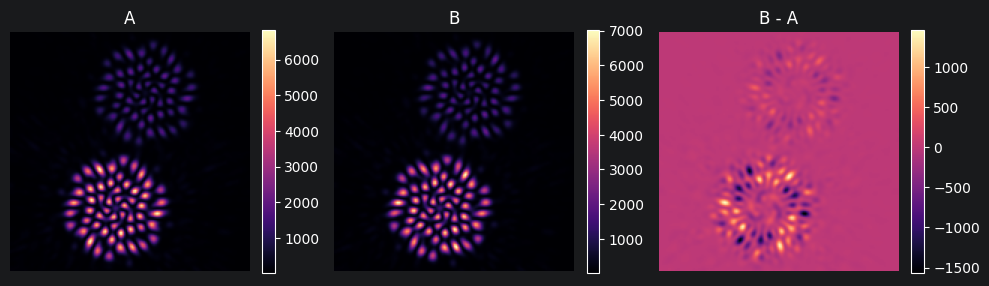

In [6]:
if catalog is not None and example_pair is not None:
    with catalog.image_reader(cache_size=2) as reader:
        image_a = reader.get(example_pair.sample_a_index)
        image_b = reader.get(example_pair.sample_b_index)
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for ax, image, title in zip(axes, [image_a, image_b, image_b - image_a], ["A", "B", "B - A"]):
        im = ax.imshow(image, origin="lower", cmap="magma")
        ax.set_title(title)
        ax.set_axis_off()
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    print("target delta z:", np.asarray(example_pair.target_delta_z))
    print("target delta theta:", np.asarray(example_pair.target_delta_theta))

## 6. Shared Encoder

A shared encoder means the same CNN instance and weights process both images: `h_A = E(I_A)` and `h_B = E(I_B)`. Weight sharing keeps the embedding coordinate system common, so `h_B - h_A` is meaningful as a learned relative feature. `concat_diff = [h_A, h_B, h_B - h_A]` is the default because it keeps relative information while retaining absolute-state context that may matter for nonlinear corrections.

In [7]:
import torch
from dluxshera.ml.models import build_pairwise_correction_model, count_parameters


model_config = {
    "comparator": "concat_diff",
    "embedding_dim": 128,
    "adaptive_pool_shape": [4, 4],
}

model = None
if torch is not None and catalog is not None:
    model = build_pairwise_correction_model(catalog.science_dim, model_config)
    print("model:", model.__class__.__name__)
    print("comparator:", model.comparator)
    print("trainable parameters:", count_parameters(model))


model: PairwiseCorrectionCNN
comparator: concat_diff
trainable parameters: 767220


## 7. Model Architecture Visualization

The architecture figures are generated from the actual model instance. Artifacts are written outside `RUN_DIR` so they are not removed by the later training call with `overwrite=True`.

The baseline uses a shared CNN encoder to map the reference and perturbed images into embeddings. The embeddings are combined by the configured pairwise comparator and passed to a regression head.

### Pairwise Model Overview

### Shared CNN Encoder


In [8]:
import base64
from IPython.display import HTML, IFrame, display
from dluxshera.ml.visualization import (
    ArchitectureVisualizationError,
    render_pairwise_correction_architecture_set,
    resolve_pdflatex,
)


def display_pdf(path, *, height=620):
    encoded = base64.b64encode(Path(path).read_bytes()).decode("ascii")
    display(IFrame(src=f"data:application/pdf;base64,{encoded}", width="100%", height=height))


architecture = None
if torch is not None and model is not None and catalog is not None:
    architecture_input_shape = (1, *catalog.sample_shape[-2:])
    compile_architecture_pdf = resolve_pdflatex() is not None
    try:
        architecture = render_pairwise_correction_architecture_set(
            model,
            input_shape=architecture_input_shape,
            model_config=model_config,
            output_dir=ARCHITECTURE_DIR,
            compile_pdf=compile_architecture_pdf,
        )
    except ArchitectureVisualizationError as exc:
        print("Architecture visualization failed:", exc)
    else:
        overview = architecture.overview
        encoder = architecture.encoder
        print("Backend:", overview.backend)
        print("Input:", " x ".join(str(v) for v in overview.metadata["input_shape"]))
        print("Shared embedding:", overview.metadata["embedding_dim"])
        print(
            "Comparator:",
            f"{overview.metadata['comparator']} ({overview.metadata['comparator_dim']})",
        )
        print("Output:", overview.metadata["output_dim"], "science-parameter corrections")
        for label, rendered in (("Pairwise Model Overview", overview), ("Shared CNN Encoder", encoder)):
            print(f"{label} TeX:", rendered.tex_path)
            print(f"{label} metadata:", rendered.metadata_path)
            if rendered.pdf_path is not None:
                print(f"{label} PDF:", rendered.pdf_path)
                display(HTML(f"<h3>{label}</h3>"))
                display_pdf(rendered.pdf_path)
            else:
                print(f"{label} PDF not rendered because `pdflatex` is not available; the .tex source was written.")
else:
    print("Set PREPARED_ROOT and build the model before rendering the architecture.")


Backend: PlotNeuralNet/TikZ
Input: 1 x 160 x 160
Shared embedding: 128
Comparator: concat_diff (384)
Output: 20 science-parameter corrections
Pairwise Model Overview TeX: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/visualizations/S01-E00/pairwise_correction_model_overview.tex
Pairwise Model Overview metadata: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/visualizations/S01-E00/pairwise_correction_model_overview.json
Pairwise Model Overview PDF: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/visualizations/S01-E00/pairwise_correction_model_overview.pdf


Shared CNN Encoder TeX: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/visualizations/S01-E00/shared_cnn_encoder_detail.tex
Shared CNN Encoder metadata: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/visualizations/S01-E00/shared_cnn_encoder_detail.json
Shared CNN Encoder PDF: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/visualizations/S01-E00/shared_cnn_encoder_detail.pdf


## 8. Tensor And Embedding Shapes

Downsampling trades pixel resolution for larger receptive fields and lower memory. This baseline keeps a small pooled spatial grid before the embedding rather than collapsing immediately to one global average.

In [9]:
if torch is not None and model is not None and example_pair is not None:
    x_a = torch.from_numpy(image_a.astype("float32")).unsqueeze(0).unsqueeze(0)
    x_b = torch.from_numpy(image_b.astype("float32")).unsqueeze(0).unsqueeze(0)
    pred, h_a, h_b = model(x_a, x_b, return_embeddings=True)
    print("input:", tuple(x_a.shape))
    print("embedding:", tuple(h_a.shape))
    print("prediction:", tuple(pred.shape))

input: (1, 1, 160, 160)
embedding: (1, 128)
prediction: (1, 20)


## 9. Image Scaling And Noise

This regression baseline avoids per-image L2 normalization because that can erase flux and amplitude information. The default transform is one scalar intensity scale derived only from the training partition. Prepared images stay noiseless; optional photon/read noise is applied dynamically to `B` when enabled.

In [10]:
from dluxshera.ml import NoiseConfig, fit_intensity_scaler

if catalog is not None and split_registry is not None:
    train_indices = catalog.indices_for_groups(
        science_groups=split_registry.science_groups("train"),
        nuisance_groups=split_registry.nuisance_groups("train"),
    )
    scaler = fit_intensity_scaler(catalog, train_indices, mode="global_max_abs", max_samples=64)
    noise = NoiseConfig(enabled=False, apply_to="observation")
    print("scaler:", scaler.to_dict())
    print("noise:", noise.to_dict())

scaler: {'mode': 'global_max_abs', 'scale': 7667.583984375, 'sample_count': 64, 'statistic': 'max(abs(image)) over selected training samples', 'amplitude_preserving': True, 'per_image_normalization': False}
noise: {'enabled': False, 'apply_to': 'observation', 'photon_noise': True, 'read_noise': False, 'read_noise_sigma': None, 'seed': 0, 'training_dynamic': True, 'negative_policy': 'raise'}


## 10. Frozen Evaluation Manifest

Validation and test comparisons should use fixed pair manifests. The same `pair_record_id`, `sample_a_id`, and `sample_b_id` keys can later join CNN predictions to a local-linear physics baseline without changing the training loop.

In [11]:
from dluxshera.ml import generate_frozen_pair_manifest, load_pair_manifest, write_pair_manifest

validation_pairs = None
if catalog is not None and split_registry is not None:
    if VALIDATION_PAIRS_DIR.exists():
        validation_pairs = load_pair_manifest(VALIDATION_PAIRS_DIR, catalog=catalog, split_registry=split_registry)
    else:
        validation_pairs = generate_frozen_pair_manifest(
            catalog, split_registry, policy=policy, split="validation", seed=101, pairs_per_slice=64
        )
        write_pair_manifest(VALIDATION_PAIRS_DIR, validation_pairs)
    print(json.dumps(validation_pairs.summary(), indent=2))

{
  "artifact_id": "PAIR-EVAL-v1",
  "pair_count": 256,
  "pair_family_counts": {
    "same_nuisance_different_science": 256
  },
  "eval_slice_counts": {
    "heldout_science_heldout_nuisance": 128,
    "heldout_science_seen_nuisance": 128
  },
  "distance_summary": {
    "min": 100.0,
    "max": 4176.12255859375,
    "mean": 947.3059573173523,
    "p50": 806.2257690429688,
    "p90": 1607.7867431640625
  }
}


## 11. S01-E00 Tiny Overfit

E00 is a pipeline sanity check, not a generalization result. It verifies image loading, ordered-pair target construction, shared-CNN gradients, optimizer updates, checkpointing, and metrics artifacts on a tiny noiseless run.

In [12]:
if torch is not None and catalog is not None and split_registry is not None:
    from dluxshera.ml.training import default_s01_e00_config, resolve_device, train_pairwise_correction
    config = default_s01_e00_config()
    config["device"] = "auto"
    print("resolved device:", resolve_device(config["device"]))
    config["training"]["epochs"] = 25
    config["training"]["pairs_per_epoch"] = 256
    print(config["pair_policy"])
    summary = train_pairwise_correction(
        config=config,
        prepared_root=PREPARED_ROOT,
        split_registry_path=SPLIT_REGISTRY_PATH,
        output_dir=RUN_DIR,
        overwrite=True,
    )
    print(json.dumps(summary, indent=2))
else:
    print("Install PyTorch and set PREPARED_ROOT before running E00.")

resolved device: mps
{'policy_id': 's01_clean_same_pair_grid_v1', 'family_weights': {'same_nuisance_different_science': 1.0}, 'same_pair_id': True, 'min_fisher_distance': 0.0, 'max_fisher_distance': 5000.0, 'include_reverse': True, 'max_sampling_attempts': 4000}
{
  "output_dir": "/Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/S01/S01-E00/S01-E00-R001",
  "run_id": "S01-E00-R001",
  "best_epoch": 23,
  "best_validation_loss": 81098.39559529425,
  "metrics_path": "/Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/S01/S01-E00/S01-E00-R001/metrics.json",
  "checkpoint_best": "/Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/S01/S01-E00/S01-E00-R001/checkpoint_best.pt"
}


## 12. History And Metrics Plots

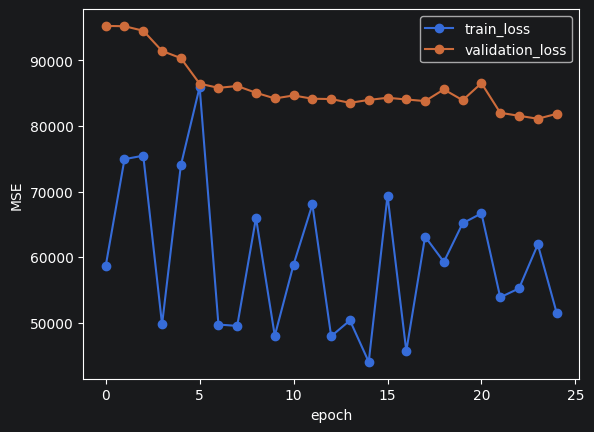

{
  "best_epoch": 23,
  "best_validation_loss": 81098.39559529425,
  "validation": {
    "by_distance_bin": {
      "bin_edges": [0.0, 100.0, 250.0, 500.0, 1000.0, 2000.0, 5000.0],
      "below_range_count": 0,
      "above_range_count": 0,
      "outside_range_count": 0,
      "bins": {
        "0-100": {
        "fisher_alignment_cosine_mean": 0.35366959684399046,
        "fisher_correction_norm_ratio_mean": 0.39877862795668295,
        "fisher_mean_vector_error_norm": 917.3849228177214,
        "fisher_median_vector_error_norm": 758.990222090973,
        "fisher_overall_rmse": 284.7778003905751,
        "fisher_per_parameter_mae": {
          "optics.plate_scale_as_per_pix": 271.5929297488183,
          "optics.primary.zernike_coeffs_nm[0]": 71.44227422913536,
          "optics.primary.zernike_coeffs_nm[1]": 101.96265560109168,
          "optics.primary.zernike_coeffs_nm[2]": 80.1309999935329,
          "optics.primary.zernike_coeffs_nm[3]": 97.36241892911494,
          "optics.prim

In [13]:
if (RUN_DIR / "history.csv").exists():
    import pandas as pd
    history = pd.read_csv(RUN_DIR / "history.csv")
    ax = history.plot(x="epoch", y=["train_loss", "validation_loss"], marker="o")
    ax.set_ylabel("MSE")
    plt.show()
    metrics = json.loads((RUN_DIR / "metrics.json").read_text())
    print(json.dumps(metrics, indent=2)[:3000])

## 13. Predicted Vs True Corrections

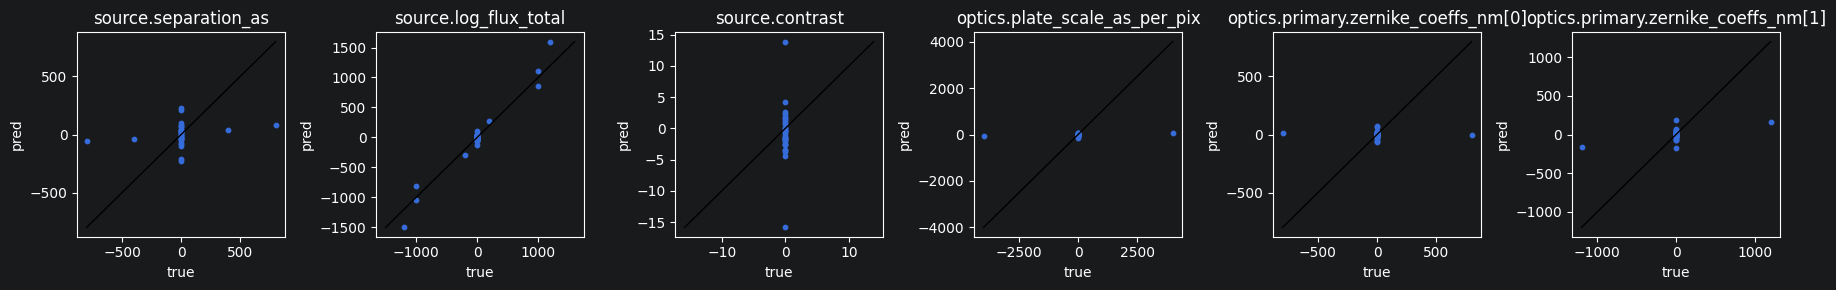

In [14]:
pred_path = RUN_DIR / "evaluation_predictions.npz"
if pred_path.exists():
    data = np.load(pred_path)
    y_true = data["y_true_z"]
    y_pred = data["y_pred_z"]
    n = min(y_true.shape[1], 6)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3), squeeze=False)
    for j, ax in enumerate(axes.ravel()):
        ax.scatter(y_true[:, j], y_pred[:, j], s=10)
        lo = min(y_true[:, j].min(), y_pred[:, j].min())
        hi = max(y_true[:, j].max(), y_pred[:, j].max())
        ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
        ax.set_title(catalog.parameter_labels[j] if catalog is not None else f"z[{j}]")
        ax.set_xlabel("true")
        ax.set_ylabel("pred")
    plt.tight_layout()

## 14. Comparator Switch

In [15]:
from dluxshera.ml.visualization import render_pairwise_correction_model_overview

if torch is not None and catalog is not None:
    difference_model_config = {**model_config, "comparator": "difference"}
    difference_model = build_pairwise_correction_model(catalog.science_dim, difference_model_config)
    print("difference comparator model parameters:", count_parameters(difference_model))
    difference_architecture = render_pairwise_correction_model_overview(
        difference_model,
        input_shape=(1, *catalog.sample_shape[-2:]),
        model_config=difference_model_config,
        output_dir=ARCHITECTURE_DIR,
        basename="pairwise_correction_model_overview_difference",
        compile_pdf=False,
    )
    print("difference comparator overview TeX:", difference_architecture.tex_path)


difference comparator model parameters: 701684
difference comparator overview TeX: /Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/ML Training Datasets/preprocessed/studies/visualizations/S01-E00/pairwise_correction_model_overview_difference.tex


## 15. Load External Checkpoint

In [16]:
CHECKPOINT_PATH = RUN_DIR / "checkpoint_best.pt"
if torch is not None and catalog is not None and CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
    loaded_model = build_pairwise_correction_model(catalog.science_dim, checkpoint["config"].get("model"))
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model.eval()
    print("loaded epoch:", checkpoint["epoch"])

loaded epoch: 23


### Reverse consistency check

- f(A,B) + f(B,A) should be close to zero for a well-trained model. This is a sanity check for the shared encoder and the pairwise correction model.

In [17]:
if torch is not None and loaded_model is not None and example_pair is not None:
    with torch.no_grad():
        f_ab = loaded_model(x_a, x_b).detach().numpy()[0]
        f_ba = loaded_model(x_b, x_a).detach().numpy()[0]
    print("f(A,B) + f(B,A):", f_ab + f_ba)

f(A,B) + f(B,A): [ -29663.562  -254152.06    -53939.523   207821.62    124277.99
   83255.125    67985.07    -81890.39     19611.938    23366.875
   13167.5625 -115630.5     -41388.332    40536.58    -85306.766
   83998.85    227966.45    185596.47     10724.656   -14405.836 ]
